In [1]:
!pip install imutils
!pip install pytesseract
!pip install easyocr

In [4]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import imutils
import pytesseract
import easyocr

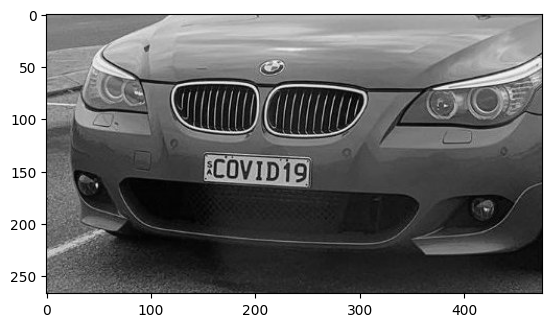

In [7]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('image2.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

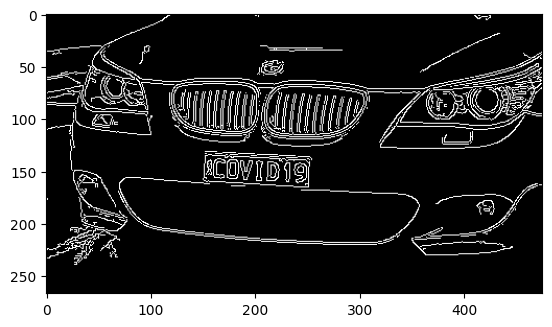

In [8]:
bfilter = cv2.bilateralFilter(gray, 11, 17, 17) #Noise reduction
edged = cv2.Canny(bfilter, 30, 200) #Edge detection
plt.imshow(cv2.cvtColor(edged, cv2.COLOR_BGR2RGB))

In [9]:
import imutils

keypoints = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(keypoints)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

In [10]:
location = None
for contour in contours:
    approx = cv2.approxPolyDP(contour, 10, True)
    if len(approx) == 4:
        location = approx
        break

In [11]:
location

array([[[152, 136]],

       [[248, 139]],

       [[251, 164]],

       [[153, 160]]], dtype=int32)

In [12]:
import numpy as np

mask = np.zeros(gray.shape, np.uint8)
new_image = cv2.drawContours(mask, [location], 0,255, -1)
new_image = cv2.bitwise_and(img, img, mask=mask)

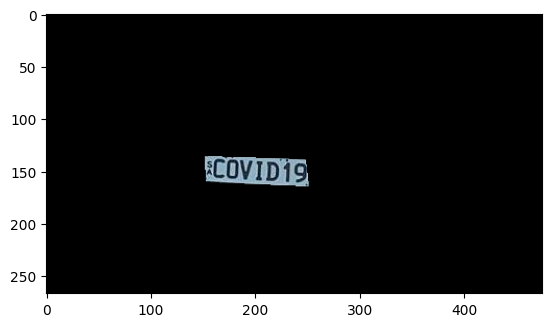

In [13]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))

In [14]:
(x,y) = np.where(mask==255)
(x1, y1) = (np.min(x), np.min(y))
(x2, y2) = (np.max(x), np.max(y))
cropped_image = gray[x1:x2+1, y1:y2+1]

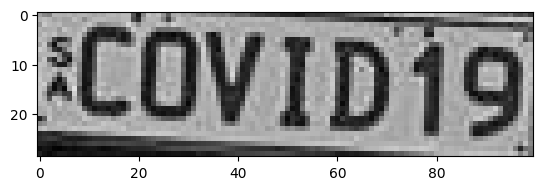

In [15]:
plt.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))

In [16]:
import easyocr

reader = easyocr.Reader(['en'])
result = reader.readtext(cropped_image)

print(result)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


[([[0, 0], [100, 0], [100, 29], [0, 29]], 'ICOVIDT9', np.float64(0.5267129442509115))]


C:\Users\Thinkpad\easyocr_env\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


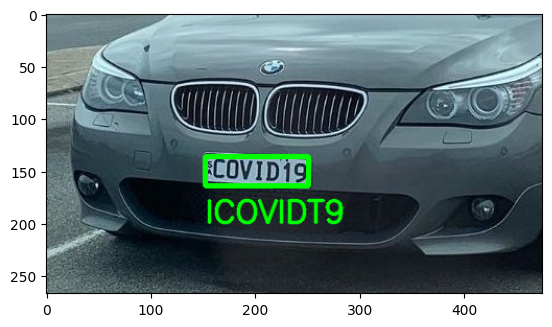

In [17]:
text = result[0][-2]
font = cv2.FONT_HERSHEY_SIMPLEX
res = cv2.putText(img, text=text, org=(approx[0][0][0], approx[1][0][1]+60), fontFace=font, fontScale=1, color=(0,255,0), thickness=2, lineType=cv2.LINE_AA)
res = cv2.rectangle(img, tuple(approx[0][0]), tuple(approx[2][0]), (0,255,0),3)
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))

In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="97OcELWScWtx4E5QCQRr")
project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
version = project.version(11)
dataset = version.download("yolov5")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plate-Recognition-11 in yolov5pytorch:: 100%|█| 20262/20262 [00:21<00:00, 935


In [ ]:
import cv2
import pytesseract
import imutils
import re
import os

# Optional: Set path to Tesseract if it's not in PATH
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

# Video path (Update this path and use raw string to avoid encoding issues)
video_path = r"C:\Users\Thinkpad\ANPR.mp4"  # rename your video for cleaner handling

# Open video file instead of webcam
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("❌ Error: Could not open video file.")
    exit()

detected_plates = set()

while True:
    ret, frame = cap.read()
    if not ret:
        print("📽️ End of video or read error.")
        break

    frame = imutils.resize(frame, width=600)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Dummy plate region (you should replace with actual detection logic)
    x, y, w, h = 100, 200, 200, 50  # Example coordinates

    plate_region = gray[y:y + h, x:x + w]
    plate_region = cv2.resize(plate_region, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    plate_region = cv2.bilateralFilter(plate_region, 11, 17, 17)
    plate_region = cv2.adaptiveThreshold(plate_region, 255,
                                         cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY, 115, 1)

    # OCR processing
    text = pytesseract.image_to_string(plate_region, config='--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789')
    cleaned_text = re.sub(r'[^A-Z0-9]', '', text.upper())

    if 4 <= len(cleaned_text) <= 12:
        detected_plates.add(cleaned_text)
        cv2.putText(frame, cleaned_text, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (36, 255, 12), 2)

    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.imshow("License Plate Recognition", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

# Print all detected plates at the end
print("✅ Detected Plates:")
print(detected_plates)


In [6]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())


2.7.0+cpu
False
